<a href="https://colab.research.google.com/github/springboardmentor0328/Image_Recognition_System_Infosys_Internship_Oct2024/blob/Gayathri_Pamarthi/Face_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

6 face(s) found


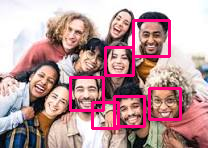

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow


# Load the pre-trained face detector
face_classifier = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')

# Load the image and convert it to grayscale
image = cv2.imread('/content/PersonE.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces in the grayscale image
faces = face_classifier.detectMultiScale(gray, 1.2, 1)

# Check if faces were found
if len(faces) == 0:
    print("No faces found")
else:
    print(f"{len(faces)} face(s) found")

# Draw rectangles around detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (127, 0, 255), 2)

# Display the image with the detected faces
cv2_imshow(image)

# Clean up
cv2.waitKey(0)
cv2.destroyAllWindows()


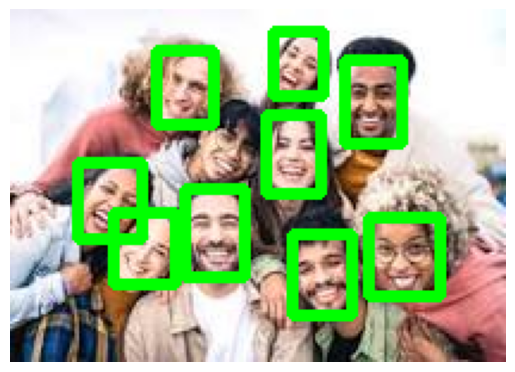

In [ ]:
import cv2
import numpy as np
from google.colab import files

# Step 1: Load the model
net = cv2.dnn.readNetFromCaffe('/content/deploy.prototxt', '/content/res10_300x300_ssd_iter_140000.caffemodel')

# Step 2: Load the image
image = cv2.imread('/content/PersonE.jpg')
(h, w) = image.shape[:2]

# Step 3: Prepare input blob
blob = cv2.dnn.blobFromImage(cv2.resize(image, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

# Step 4: Set the blob as input and perform face detection
net.setInput(blob)
detections = net.forward()

# Step 5: Loop over the detections
for i in range(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    # Only consider detections with confidence above a threshold (e.g., 60%)
    if confidence > 0.6:
        # Get coordinates of the bounding box
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")

        # Bounding box
        cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 3)

# Step 6: Display the output image with detected faces
# Convert the image from BGR (OpenCV default) to RGB for displaying in Colab
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 7: Use matplotlib to display the image in the notebook
import matplotlib.pyplot as plt
plt.imshow(image_rgb)
plt.axis('off')  # Hide axis
plt.show()


In [ ]:
import cv2
import numpy as np

# Step 1: Load the pre-trained face detection model
net = cv2.dnn.readNetFromCaffe('/content/deploy.prototxt', '/content/res10_300x300_ssd_iter_140000.caffemodel')

# Step 2: Load the input video
video_input = '/content/video.mp4'
video_capture = cv2.VideoCapture(video_input)

# Get video properties for output
fps = int(video_capture.get(cv2.CAP_PROP_FPS))
frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Step 3: Define codec and create VideoWriter object to save the output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_video = '/content/output_video.mp4'
out = cv2.VideoWriter(output_video, fourcc, fps, (frame_width, frame_height))

# Step 4: Loop through each frame of the video
while True:
    ret, frame = video_capture.read()

    if not ret:
        break  # Exit if the video ends
    (h, w) = frame.shape[:2]

    # Step 5: Prepare input blob from the frame
    blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

    # Step 6: Perform face detection on the blob
    net.setInput(blob)
    detections = net.forward()

    # Step 7: Loop over the detections
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        # Only consider detections with confidence above a threshold (e.g., 60%)
        if confidence > 0.6:
            # Get coordinates of the bounding box
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            # Draw bounding box around the face
            cv2.rectangle(frame, (startX, startY), (endX, endY), (0, 255, 0), 3)

    # Step 8: Write the frame with detected faces to the output video
    out.write(frame)

# Step 9: Release the video objects
video_capture.release()
out.release()

# Optional: Show a message when the processing is done
print(f"Face detection complete. Output saved as {output_video}.")


Face detection complete. Output saved as /content/output_video.mp4.


In [ ]:
import dlib
print(dlib.__version__)

19.24.2


In [ ]:
import cv2
import numpy as np
import dlib

# 1: Load the pre-trained face detection model from OpenCV
net = cv2.dnn.readNetFromCaffe('/content/deploy.prototxt', '/content/res10_300x300_ssd_iter_140000.caffemodel')

# 2: Load the pre-trained dlib face recognition model
face_recognition_model = dlib.face_recognition_model_v1('/content/dlib_face_recognition_resnet_model_v1.dat')
face_detector = dlib.get_frontal_face_detector()
shape_predictor = dlib.shape_predictor('/content/shape_predictor_68_face_landmarks.dat')

# Calculate face embeddings
def get_face_embeddings(image):
    if image is None:
        print("Image not found or couldn't be loaded.")
        return None, None

    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces using dlib
    faces = face_detector(gray)
    if len(faces) == 0:
        return None, None

    # Get the landmarks for the first face
    shape = shape_predictor(gray, faces[0])

    # Compute face embeddings using the pre-trained dlib model
    face_embedding = face_recognition_model.compute_face_descriptor(image, shape)
    return np.array(face_embedding), faces[0]

# 3: Load the reference image and compute its face embeddings
train_image = cv2.imread('/content/Virat1.jpg')
train_embedding, train_face = get_face_embeddings(train_image)

if train_embedding is None:
    print("No face detected in the reference image")
    exit()

# Draw the bounding box around the face in the train image
(x, y, w, h) = (train_face.left(), train_face.top(), train_face.width(), train_face.height())
cv2.rectangle(train_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

# 4: Process each test image
test_image_paths = ['/content/Virat1.jpg', '/content/Virat6.jpg', '/content/Virat3.jpg', '/content/dhoni.jpg']

processed_files = []

for test_image_path in test_image_paths:
    test_image = cv2.imread(test_image_path)

    # Check if the test image was loaded successfully
    if test_image is None:
        print(f"Could not load image: {test_image_path}. Skipping.")
        continue

    # 5: Detect and extract face embeddings for the test image
    test_embedding, test_face = get_face_embeddings(test_image)

    if test_embedding is None:
        print(f"No face detected in {test_image_path}")
        continue

    # 6: Compare the train embedding with the test embedding (Euclidean distance)
    distance = np.linalg.norm(train_embedding - test_embedding)

    # 7: Decide if the faces match
    if distance < 0.4:
        label = "Match"
        color = (0, 255, 0)
    else:
        label = "Not Match"
        color = (0, 0, 255)

    # Draw the bounding box around the face in the test image
    (x, y, w, h) = (test_face.left(), test_face.top(), test_face.width(), test_face.height())
    cv2.rectangle(test_image, (x, y), (x + w, y + h), color, 2)

    # Display distance on the image
    cv2.putText(test_image, label, (x, y - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)  # Adjust y position
    cv2.putText(test_image, f"Dist: {distance:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)  # Add distance

    # Save the output image with the bounding box and label
    output_path = f"/content/output_{test_image_path.split('/')[-1]}"
    cv2.imwrite(output_path, test_image)
    processed_files.append(output_path)
    print(f"Processed {test_image_path}. Output saved at {output_path}")


Processed /content/Virat1.jpg. Output saved at /content/output_Virat1.jpg
Processed /content/Virat6.jpg. Output saved at /content/output_Virat6.jpg
No face detected in /content/Virat3.jpg
Processed /content/dhoni.jpg. Output saved at /content/output_dhoni.jpg
